In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# 경로 설정 (사용자 환경에 맞게 유지)
root_path = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.generals.utils import load_hdr
from src.gradient_tone_mapping.tonemap import tonemap, _step1_log_mapping

# 데이터 로드
input_path = "../../data/image_sample/1_Halo_Corner_Bottom/01_3072 x 2048_pos(1)_NG.hdr"
hdr = load_hdr(input_path)

# Step 1: Log Mapping 적용
log_map = _step1_log_mapping(hdr)

# 시각화를 위한 정규화 (0-255)
log_display = (log_map * 255)
log_display = np.clip(log_display, 0, 255).astype(np.uint8)

# 시각화: 이미지와 히스토그램을 가로로 배치
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 로그 변환 이미지 출력
axes[0].imshow(log_display, cmap='gray')
axes[0].set_title('Logarithmized Image (Step 1)')
axes[0].axis('off')

# 2. 히스토그램 출력
# ravel()을 사용하여 2차원 배열을 1차원으로 펼쳐서 계산합니다.
axes[1].hist(log_map.ravel(), bins=256, color='gray', alpha=0.7)
axes[1].set_title('Histogram of Log Map (Raw)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Original max intensity (L_max): 651264.0

Processing with gamma:  0.2

E min = 0.000000, E max = 0.354812, E mean = 0.000505

K min = 1.23, K max = 92.93, K mean = 26.18
1번째요~!!
2번째요~!!
3번째요~!!
4번째요~!!
5번째요~!!
6번째요~!!
7번째요~!!
8번째요~!!
End at iteration 8 with MAE = 0.530667
f_c (rightmost trough) = 0.9863
Original max intensity (L_max): 651264.0

Processing with gamma:  0.4

E min = 0.000000, E max = 0.354812, E mean = 0.000505

K min = 1.51, K max = 8636.35, K mean = 2093.76
1번째요~!!
2번째요~!!
3번째요~!!
4번째요~!!
5번째요~!!
6번째요~!!
7번째요~!!
8번째요~!!
End at iteration 8 with MAE = 0.529400
f_c (rightmost trough) = 0.9941
Original max intensity (L_max): 651264.0

Processing with gamma:  0.6

E min = 0.000000, E max = 0.354812, E mean = 0.000505

K min = 1.86, K max = 802593.25, K mean = 192829.06
1번째요~!!
2번째요~!!
3번째요~!!
4번째요~!!
5번째요~!!
6번째요~!!
7번째요~!!
8번째요~!!
End at iteration 8 with MAE = 0.530601
f_c (rightmost trough) = 0.9902
Original max intensity (L_max): 651264.0

Processing with gamma:  0.8

E 

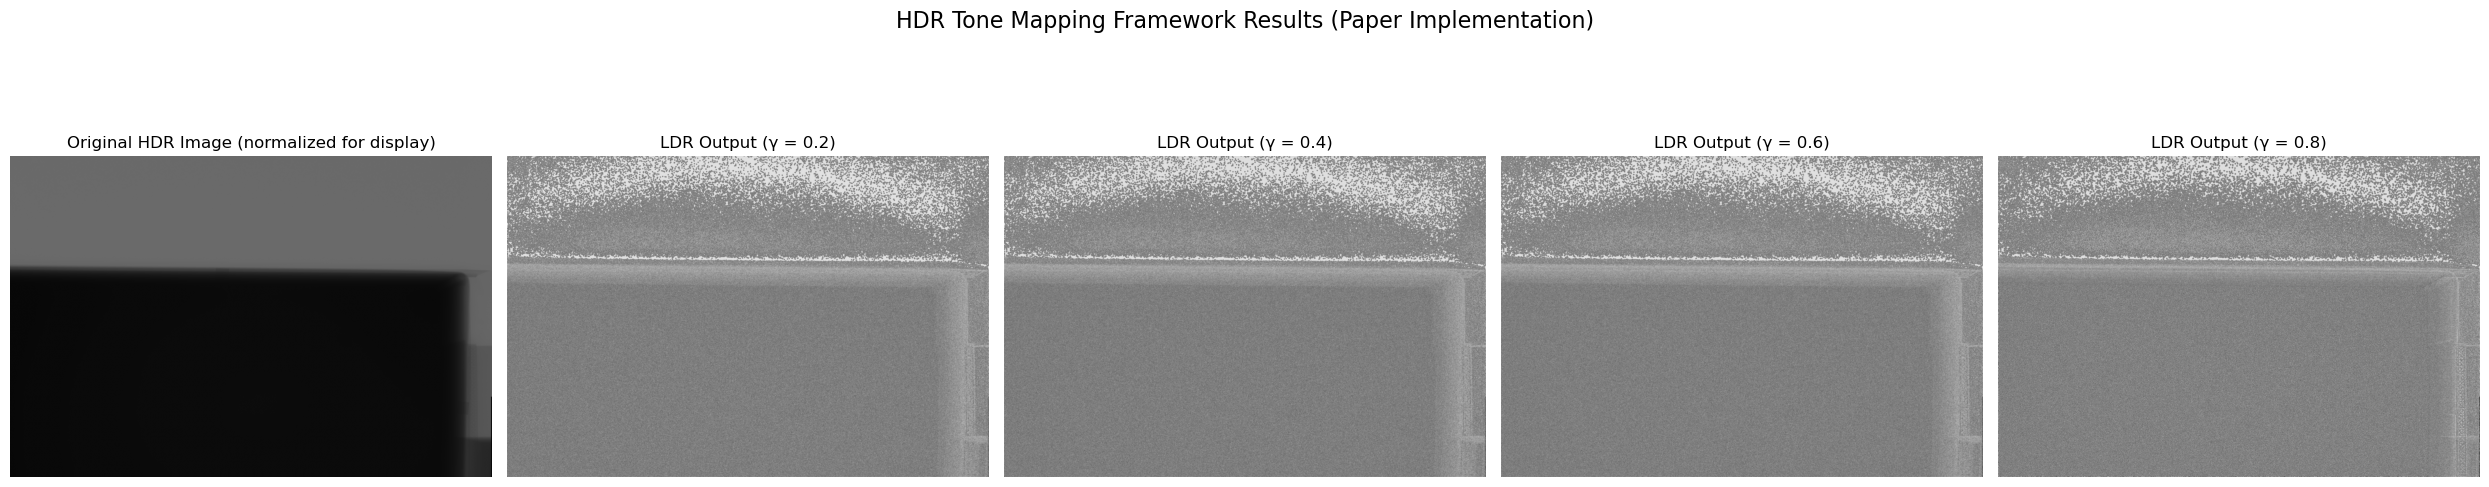


All results plotted successfully in Jupyter Notebook.


In [1]:
import sys
import os
root_path = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.generals.utils import load_hdr, save_ldr

from src.generals.utils import load_hdr, save_ldr
from src.gradient_tone_mapping.tonemap import tonemap
import matplotlib.pyplot as plt
import numpy as np
import cv2
from typing import List, Any
from src.gradient_tone_mapping.parameters import Parameters 
from src.generals.preprocess import preprocess
from src.generals.postprocess import postprocess


params = Parameters()

def run(input_path: str, output_path: str = None, gamma_values: List[float]=params.gamma_values):
    hdr = load_hdr(input_path)
    #preprocess here. But, because we do logarithm normalization, I think we don't need gamma correction as pre-processing.
    #hdr = preprocess(hdr, gamma=1.0)

    # =============================================
    # Prepare for plotting (just for exp)
    # =============================================
    fig, axs = plt.subplots(1, len(gamma_values) + 1, figsize=(5 * (len(gamma_values) + 1), 6))
    fig.suptitle("HDR Tone Mapping Framework Results (Paper Implementation)", fontsize=16)

    # Plot original input (normalized for display)
    I_display = np.clip(hdr) if hdr.max() > 0 else hdr
    axs[0].imshow(I_display, cmap='gray')
    axs[0].set_title("Original HDR Image (normalized for display)")
    axs[0].axis('off')
    

    # =============================================
    # Loop over each gamma value
    # =============================================
    for idx, gamma in enumerate(gamma_values):
        f_out = tonemap(hdr, gamma=gamma) # f_out ~ ldr
        #f_out = postprocess(f_out, gamma=1.0)

        # =============================================
        # Plot the LDR output (just for exp)
        # =============================================
        ldr_display = (f_out * 255.0).clip(0, 255).astype(np.uint8)
        axs[idx + 1].imshow(ldr_display, cmap='gray')
        axs[idx + 1].set_title(f"LDR Output (γ = {gamma})")
        axs[idx + 1].axis('off')

    plt.tight_layout()
    plt.show()
    print("\nAll results plotted successfully in Jupyter Notebook.")

# ====================== USAGE (in Jupyter Notebook) ======================
# Just run the cell below:
run("../../data/image_sample/5_Corner_Cathode_5/02_3072 x 3072_pos(2)_NG.hdr")
# "input.hdr" is the "poor_battery_images_dataset.zip/5_Corner_Cathode_5/02_3072 x 3072_pos(2)_NG.hdr" file, but i renamed it to "input.hdr" for simplicity.
# you can test with any file, just update the image path and run ..